In [29]:
import hashlib
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score

In [30]:
# สร้างข้อมูลจำลอง 1000 รายการ (0 = Normal Log, 1 = Malware Log)
NUM_NODES = 5
NODE_NAMES = ["A", "B", "C", "D", "E"]

# ค่าคุมการทดลอง
ROUNDS = 25        # จำนวนรอบของ swarm
LOCAL_EPOCHS = 1   # เทรนในเครื่องกี่ epoch ต่อรอบ ก่อนส่งพารามิเตอร์ให้ leader
ETA = 0.005        # learning rate แบบคงที่ เพื่อให้เส้นกราฟอ่านทิศทางได้
INIT_STD = 1.0     # ความกระจายของค่าน้ำหนักเริ่มต้น (แต่ละโหนดสุ่มเอง)
CLASSES = np.array([0, 1])

X, y = make_classification(n_samples=1000, n_features=10, random_state=42)

# กันข้อมูล 200 รายการสุดท้ายไว้เป็นชุดทดสอบกลาง (ไม่มีโหนดไหนเห็นตอนเทรน)
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

# จำลองสภาพจริง (Non-IID): แต่ละโหนดเก็บ log ปริมาณไม่เท่ากัน และสัดส่วน malware ต่างกัน
# รูปแบบ: ชื่อโหนด -> (จำนวนข้อมูล, สัดส่วน malware)
NODE_PROFILES = {
    "A": (240, 0.50),  # องค์กรใหญ่ ข้อมูลเยอะและสมดุล
    "B": (160, 0.40),  # ข้อมูลปานกลาง ค่อนข้างสมดุล
    "C": (110, 0.95),  # เจอแต่ malware แทบไม่เห็น log ปกติ
    "D": (60,  0.92),  # ข้อมูลน้อยและเอียงหนัก -> โหนดที่อ่อนที่สุด
    "E": (110, 0.12),  # เจอแต่ log ปกติ แทบไม่เห็น malware
}

# สุ่มแจกข้อมูลให้แต่ละโหนดตาม profile (ไม่ให้ข้อมูลซ้ำกันระหว่างโหนด)
rng = np.random.default_rng(42)
pool = {c: list(rng.permutation(np.where(y_train == c)[0])) for c in (0, 1)}

X_nodes, y_nodes = {}, {}
for name, (n_samples, malware_ratio) in NODE_PROFILES.items():
    n_malware = int(n_samples * malware_ratio)
    n_normal = n_samples - n_malware
    idx = [pool[1].pop() for _ in range(n_malware)] + [pool[0].pop() for _ in range(n_normal)]
    idx = rng.permutation(idx)
    X_nodes[name], y_nodes[name] = X_train[idx], y_train[idx]

In [31]:
for name in NODE_NAMES:
    print(f"Node {name}: X={X_nodes[name].shape}, y={y_nodes[name].shape}, "
          f"malware ratio={y_nodes[name].mean():.2f}")

print()
print("shape of X_test:", X_test.shape)
print("shape of y_test:", y_test.shape)

Node A: X=(240, 10), y=(240,), malware ratio=0.50
Node B: X=(160, 10), y=(160,), malware ratio=0.40
Node C: X=(110, 10), y=(110,), malware ratio=0.95
Node D: X=(60, 10), y=(60,), malware ratio=0.92
Node E: X=(110, 10), y=(110,), malware ratio=0.12

shape of X_test: (200, 10)
shape of y_test: (200,)


In [40]:
# ของจริงแต่ละโหนดตั้งต้นโมเดลของตัวเอง ไม่ได้นัดกันใช้ค่าเริ่มต้นชุดเดียวกัน
# จึงให้แต่ละโหนดสุ่มค่าน้ำหนักเริ่มต้นด้วย seed ของตัวเอง -> การเฉลี่ยพารามิเตอร์
# ต้องพิสูจน์ตัวเองว่าดึงโมเดลที่ออกจากจุดต่างกันให้มาบรรจบกันได้จริง
def make_node_model(seed, X_seed, y_seed):
    model = SGDClassifier(loss="log_loss", learning_rate="constant", eta0=ETA,
                          random_state=seed, warm_start=True)
    # partial_fit ครั้งแรกเพื่อสร้างโครง coef_/intercept_ แล้วเขียนค่าเริ่มต้นของตัวเองทับ
    model.partial_fit(X_seed[:2], y_seed[:2], classes=CLASSES)
    rng_init = np.random.default_rng(1000 + seed)
    model.coef_ = rng_init.normal(0, INIT_STD, size=model.coef_.shape)
    model.intercept_ = rng_init.normal(0, INIT_STD, size=model.intercept_.shape)
    return model


# โมเดล 2 ชุดที่ออกจากจุดเริ่มต้นเดียวกัน ต่างกันแค่ "เข้าร่วม swarm" หรือ "เทรนเดี่ยว"
swarm_models = {n: make_node_model(i, X_nodes[n], y_nodes[n]) for i, n in enumerate(NODE_NAMES)}
solo_models = {n: make_node_model(i, X_nodes[n], y_nodes[n]) for i, n in enumerate(NODE_NAMES)}

for name in NODE_NAMES:
    acc = accuracy_score(y_test, swarm_models[name].predict(X_test))
    print(f"Node {name}: accuracy before training = {acc:.2f}")

Node A: accuracy before training = 0.42
Node B: accuracy before training = 0.57
Node C: accuracy before training = 0.54
Node D: accuracy before training = 0.76
Node E: accuracy before training = 0.44


In [41]:
# [Leader Election] ระบบจริงให้ smart contract เลือก leader ของแต่ละรอบจาก state บน ledger
# ที่นี่จำลองด้วย sha256(เลขรอบ + รายชื่อผู้เข้าร่วม) ซึ่งมีคุณสมบัติที่ต้องการ 3 ข้อ
#   1. ทุกโหนดคำนวณเองได้ ไม่ต้องมีศูนย์กลางคอยสั่ง
#   2. ผลตรงกันทุกโหนด (deterministic) จึงไม่ต้องเจรจากันว่ารอบนี้ใครรวมพารามิเตอร์
#   3. ตรวจย้อนหลังได้ว่ารอบนั้นใครมีสิทธิ์ทำหน้าที่ leader
def elect_leader(round_num, participants):
    digest = hashlib.sha256(f"round-{round_num}:{','.join(participants)}".encode()).hexdigest()
    return participants[int(digest, 16) % len(participants)]


for r in range(1, 6):
    print(f"round {r} -> leader = Node {elect_leader(r, NODE_NAMES)}")

round 1 -> leader = Node D
round 2 -> leader = Node E
round 3 -> leader = Node D
round 4 -> leader = Node D
round 5 -> leader = Node C


In [34]:
def local_train(model, name):
    """เทรนด้วยข้อมูลในเครื่องของโหนดตัวเอง (ข้อมูลไม่ออกจากโหนด) แล้วคืนพารามิเตอร์ที่จะส่งขึ้น swarm"""
    for _ in range(LOCAL_EPOCHS):
        model.partial_fit(X_nodes[name], y_nodes[name], classes=CLASSES)
    return model.coef_.copy(), model.intercept_.copy()


def aggregate(updates):
    """หน้าที่ของ leader ในรอบนั้น: FedAvg ถ่วงน้ำหนักตามจำนวนข้อมูลของผู้ส่งแต่ละราย"""
    total = sum(n for _, _, n in updates)
    coef = np.sum([w * n for w, _, n in updates], axis=0) / total
    intercept = np.sum([b * n for _, b, n in updates], axis=0) / total
    return coef, intercept


def accuracy_of(coef, intercept, probe):
    """ยืมโครงโมเดลมาวัดพารามิเตอร์ชุดหนึ่งบนชุดทดสอบกลาง แล้วคืนค่าเดิมให้โมเดล"""
    saved = (probe.coef_.copy(), probe.intercept_.copy())
    probe.coef_, probe.intercept_ = coef.copy(), intercept.copy()
    acc = accuracy_score(y_test, probe.predict(X_test))
    probe.coef_, probe.intercept_ = saved
    return acc

In [35]:
# Baseline "centralized" = ยอมรวม log ของทุกองค์กรไว้ที่เดียวแล้วเทรน
# คือสิ่งที่ swarm learning ต้องการแทนที่ จึงเป็นเพดานที่เอาไว้วัดว่า swarm เข้าใกล้แค่ไหน
central_model = make_node_model(99, X_train, y_train)   # เส้นต่อรอบ ใช้ compute เท่าโหนด
CENTRAL_UPPER = accuracy_score(
    y_test, LogisticRegression(max_iter=1000).fit(X_train, y_train).predict(X_test)
)
print(f"centralized upper bound (รวมข้อมูล 800 รายการ + เทรนจนลู่เข้า): {CENTRAL_UPPER:.3f}")

centralized upper bound (รวมข้อมูล 800 รายการ + เทรนจนลู่เข้า): 0.880


In [36]:
history = {k: [] for k in ("round", "leader", "swarm", "solo_avg", "solo_min", "solo_max", "central")}
global_coef = global_intercept = None

for round_num in range(1, ROUNDS + 1):
    # รอบนี้ใครเป็น leader — ทุกโหนดคำนวณได้เองจากเลขรอบ
    leader = elect_leader(round_num, NODE_NAMES)

    updates = []
    for name in NODE_NAMES:
        # เริ่มจากโมเดลกลางของรอบก่อน แล้วเทรนต่อด้วยข้อมูลตัวเอง
        if global_coef is not None:
            swarm_models[name].coef_ = global_coef.copy()
            swarm_models[name].intercept_ = global_intercept.copy()
        coef, intercept = local_train(swarm_models[name], name)
        updates.append((coef, intercept, len(y_nodes[name])))

        # baseline "local-only": โหนดเดิมที่เลือกไม่เข้าร่วม swarm (ใช้ compute เท่ากัน)
        local_train(solo_models[name], name)

    # baseline "centralized": ศูนย์กลางที่เห็นข้อมูลของทุกโหนด
    for _ in range(LOCAL_EPOCHS):
        central_model.partial_fit(X_train, y_train, classes=CLASSES)

    # leader ของรอบนี้รวมพารามิเตอร์ที่ได้รับ -> กลายเป็นโมเดลกลางของรอบถัดไป
    global_coef, global_intercept = aggregate(updates)

    swarm_acc = accuracy_of(global_coef, global_intercept, swarm_models[leader])
    solo_accs = [accuracy_score(y_test, solo_models[n].predict(X_test)) for n in NODE_NAMES]
    central_acc = accuracy_score(y_test, central_model.predict(X_test))

    history["round"].append(round_num)
    history["leader"].append(leader)
    history["swarm"].append(swarm_acc)
    history["solo_avg"].append(float(np.mean(solo_accs)))
    history["solo_min"].append(min(solo_accs))
    history["solo_max"].append(max(solo_accs))
    history["central"].append(central_acc)

    print(f"round {round_num:2d} | leader Node {leader} | swarm {swarm_acc:.3f} | "
          f"local-only avg {np.mean(solo_accs):.3f} | centralized {central_acc:.3f}")

# จบทุกรอบแล้วกระจายโมเดลกลางรอบสุดท้ายให้ทุกโหนดถือไว้เหมือนกัน
for name in NODE_NAMES:
    swarm_models[name].coef_ = global_coef.copy()
    swarm_models[name].intercept_ = global_intercept.copy()

round  1 | leader Node D | swarm 0.710 | local-only avg 0.624 | centralized 0.720
round  2 | leader Node E | swarm 0.785 | local-only avg 0.675 | centralized 0.835
round  3 | leader Node D | swarm 0.820 | local-only avg 0.721 | centralized 0.890
round  4 | leader Node D | swarm 0.845 | local-only avg 0.755 | centralized 0.895
round  5 | leader Node C | swarm 0.855 | local-only avg 0.773 | centralized 0.890
round  6 | leader Node D | swarm 0.875 | local-only avg 0.792 | centralized 0.890
round  7 | leader Node C | swarm 0.880 | local-only avg 0.800 | centralized 0.885
round  8 | leader Node E | swarm 0.895 | local-only avg 0.807 | centralized 0.885
round  9 | leader Node E | swarm 0.895 | local-only avg 0.815 | centralized 0.885
round 10 | leader Node B | swarm 0.900 | local-only avg 0.822 | centralized 0.885
round 11 | leader Node D | swarm 0.900 | local-only avg 0.826 | centralized 0.880
round 12 | leader Node E | swarm 0.900 | local-only avg 0.831 | centralized 0.880
round 13 | leade

In [37]:
# ตรวจว่าหน้าที่ leader กระจายจริงไหม (ไม่มีโหนดไหนเป็นศูนย์กลางถาวร)
counts = Counter(history["leader"])
for name in NODE_NAMES:
    bar = "#" * counts[name]
    print(f"Node {name}: leader {counts[name]:2d}/{ROUNDS} รอบ  {bar}")

Node A: leader  3/25 รอบ  ###
Node B: leader  6/25 รอบ  ######
Node C: leader  2/25 รอบ  ##
Node D: leader  9/25 รอบ  #########
Node E: leader  5/25 รอบ  #####


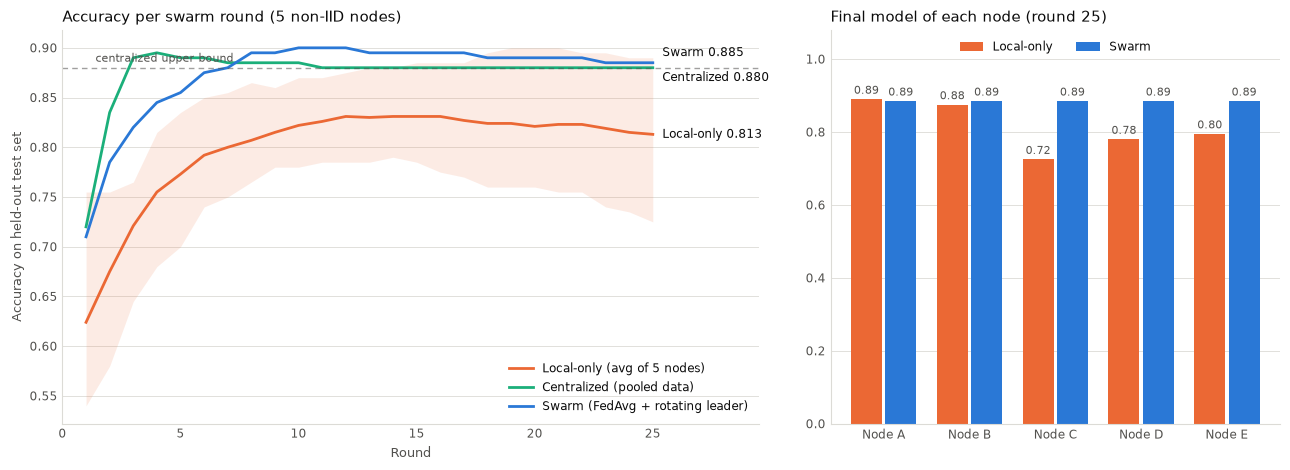

In [38]:
# สีชุด categorical ที่ผ่านการตรวจ contrast/CVD แล้ว
C_SWARM, C_SOLO, C_CENTRAL = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#dcdbd6"

rounds = history["round"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8),
                               gridspec_kw={"width_ratios": [1.55, 1]})

# --- ซ้าย: เส้นการลู่เข้าของทั้ง 3 แนวทาง ---
ax1.fill_between(rounds, history["solo_min"], history["solo_max"],
                 color=C_SOLO, alpha=0.13, linewidth=0)
ax1.plot(rounds, history["solo_avg"], color=C_SOLO, linewidth=2, label="Local-only (avg of 5 nodes)")
ax1.plot(rounds, history["central"], color=C_CENTRAL, linewidth=2, label="Centralized (pooled data)")
ax1.plot(rounds, history["swarm"], color=C_SWARM, linewidth=2, label="Swarm (FedAvg + rotating leader)")
ax1.axhline(CENTRAL_UPPER, color=INK_MUTED, linewidth=1, linestyle=(0, (4, 3)), alpha=0.55)
ax1.text(1.4, CENTRAL_UPPER + 0.006, "centralized upper bound",
         color=INK_MUTED, fontsize=8, ha="left")

# ป้ายกำกับท้ายเส้น (ไม่ต้องไล่หาสีในกล่อง legend)
for key, label, dy in (("swarm", "Swarm", 7), ("central", "Centralized", -7),
                       ("solo_avg", "Local-only", 0)):
    ax1.annotate(f" {label} {history[key][-1]:.3f}", (rounds[-1], history[key][-1]),
                 color=INK, fontsize=8.5, va="center", xytext=(4, dy), textcoords="offset points")

ax1.set_title("Accuracy per swarm round (5 non-IID nodes)", color=INK, fontsize=11, loc="left")
ax1.set_xlabel("Round", color=INK_MUTED, fontsize=9)
ax1.set_ylabel("Accuracy on held-out test set", color=INK_MUTED, fontsize=9)
ax1.set_xlim(1, ROUNDS + 4.5)
ax1.set_xticks(range(0, ROUNDS + 1, 5))
ax1.legend(loc="lower right", frameon=False, fontsize=8.5, labelcolor=INK)

# --- ขวา: โมเดลสุดท้ายของแต่ละโหนด เทียบ เทรนเดี่ยว vs เข้าร่วม swarm ---
final_solo = [accuracy_score(y_test, solo_models[n].predict(X_test)) for n in NODE_NAMES]
final_swarm = [accuracy_score(y_test, swarm_models[n].predict(X_test)) for n in NODE_NAMES]
pos = np.arange(NUM_NODES)

ax2.bar(pos - 0.2, final_solo, width=0.36, color=C_SOLO, label="Local-only")
ax2.bar(pos + 0.2, final_swarm, width=0.36, color=C_SWARM, label="Swarm")
for x, v in zip(pos - 0.2, final_solo):
    ax2.text(x, v + 0.015, f"{v:.2f}", ha="center", fontsize=8, color=INK_MUTED)
for x, v in zip(pos + 0.2, final_swarm):
    ax2.text(x, v + 0.015, f"{v:.2f}", ha="center", fontsize=8, color=INK_MUTED)

ax2.set_title(f"Final model of each node (round {ROUNDS})", color=INK, fontsize=11, loc="left")
ax2.set_xticks(pos, [f"Node {n}" for n in NODE_NAMES])
ax2.set_ylim(0, 1.08)
ax2.set_xlabel("")
ax2.legend(loc="upper center", ncol=2, frameon=False, fontsize=8.5, labelcolor=INK)

for ax in (ax1, ax2):
    ax.grid(axis="y", color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5, length=0)

fig.tight_layout()
plt.show()

In [43]:
# สรุปตัวเลขปิดท้าย
print(f"{'node':6} {'local-only':>11} {'swarm':>8} {'gain':>8}")
for name, solo, swarm in zip(NODE_NAMES, final_solo, final_swarm):
    print(f"{name:6} {solo:>11.3f} {swarm:>8.3f} {swarm - solo:>+8.3f}")

print()
print(f"centralized (per-round curve)      : {history['central'][-1]:.3f}")
print(f"centralized (converged upper bound): {CENTRAL_UPPER:.3f}")
print(f"swarm learning                    : {history['swarm'][-1]:.3f}")

node    local-only    swarm     gain
A            0.890    0.885   -0.005
B            0.875    0.885   +0.010
C            0.725    0.885   +0.160
D            0.780    0.885   +0.105
E            0.795    0.885   +0.090

centralized (per-round curve)      : 0.880
centralized (converged upper bound): 0.880
swarm learning                    : 0.885
